# Notebook to decode LSD PLA states based on spectral and temporal features

In [5]:
import pandas as pd
import numpy as np
from nilearn import plotting
from nilearn.datasets import fetch_icbm152_2009
from nilearn.regions import signals_to_img_labels
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.base import clone
from tqdm import tqdm
import seaborn as sns


In [9]:



def plot_brain_maps(signal_to_plot, title, savefig=None):
    path_Glasser = '/Brain/private/v20subra//LSD_project/src_data/Glasser_masker.nii.gz'
    mnitemp = fetch_icbm152_2009()
    
    
    nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])

    plotting.plot_img_on_surf(stat_map=nifti, views=["lateral", "medial"], hemispheres=["left", "right"], symmetric_cbar=False, title=f'{title}', cmap='inferno',vmin =np.min(signal_to_plot), threshold=0.0000000001, vmax=np.max(signal_to_plot), output_file=savefig, colorbar=False)
    plt.show()

In [12]:


def ml(df, is_single_feature=False, whichFeature=None):
    if is_single_feature:
        idx = np.argwhere(df.columns.str.startswith(f'{whichFeature}'))
        X = df.iloc[:,np.hstack(idx)]
        y = df['Target'].astype(int).values
        groups = df['Subject_ID'].values
        feature_names = df.columns[np.hstack(idx)].values

        
    else: 
        X = df.drop(columns=['Subject_ID', 'Target']).values
        y = df['Target'].astype(int).values
        groups = df['Subject_ID'].values
        feature_names = df.drop(columns=['Subject_ID', 'Target']).columns

    cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)

    param_grid = {
        'n_estimators': [25, 50, 100, 150, 200, 300],
        'max_depth': [5, 10, 50, 100, 200],
        'min_samples_split': [2, 5],
        
    }

    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        scoring='accuracy',
        cv=cv.split(X, y, groups=groups),
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X, y)

    true_best_model = grid_search.best_estimator_
    true_accuracy = grid_search.best_score_

    
    return true_best_model, true_accuracy, feature_names, X, y, groups


def permtests(true_best_model, true_accuracy, X, y, groups, feature_names, model_family='single_feature'):
    n_permutations = 1000
    perm_accuracies = []
    perm_importances = []
    cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=42)
    print("Running permutation test...")
    for i in tqdm(range(n_permutations)):
        y_perm = np.random.permutation(y)
        perm_scores = []
        feature_importances = []

        for train_idx, test_idx in cv.split(X, y_perm, groups=groups):
            if model_family=='single_feature':
                X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            else:
                X_train, X_test = X[train_idx], X[test_idx]
                
            y_train, y_test = y_perm[train_idx], y_perm[test_idx]

            model = clone(true_best_model)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            perm_scores.append(acc)
            feature_importances.append(model.feature_importances_)
            

        perm_accuracies.append(np.mean(perm_scores))

        perm_importances.append(np.mean(feature_importances, axis=0))

    perm_accuracies = np.array(perm_accuracies)
    p_value = (np.sum(perm_accuracies >= true_accuracy) + 1) / (n_permutations + 1)
    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'empirical_importance': true_best_model.feature_importances_,
        "p_value_accuracy": p_value,
        "true_accuracy": true_accuracy
    })

    p_value_feature_importance = ((np.sum(perm_importances >= true_best_model.feature_importances_ , axis=0)+1) / (n_permutations+1))

    feature_importance_df['p_value_feature_importance'] = p_value_feature_importance
    return feature_importance_df


# Single domain ML

## Main effect - drug

In [14]:
model_type = 'main_drug'
wheretosave = f"/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/singleFeatureML/results/{model_type}"

df = pd.read_csv(f'/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/data/df_{model_type}.csv')
features = [ 'alphapeakpower', 'betapeakpower', 'highgammapower',
            "exponent", "offset", "alphapeak", "betapeak", "lzc", 'hfd']
feature_importances_main_effect_drug = {}

for feature in features:

    true_best_model, true_accuracy, feature_names, X, y, groups = ml(df=df, is_single_feature=True, whichFeature=feature)
    feature_importance_df = permtests(true_best_model, true_accuracy, X, y, groups, feature_names, model_family='single_feature')
    unthresholded_signal = feature_importance_df['empirical_importance'].values
    thresholded= unthresholded_signal*((feature_importance_df['p_value_feature_importance'] <0.05).values)

    pval_accuracy = np.unique(feature_importance_df['p_value_accuracy'].values)
    truncated_pval_accuracy = int(pval_accuracy[0] * 1e5) / 1e5

    true_accuracy = np.unique(feature_importance_df['true_accuracy'].values)
    feature_importances_main_effect_drug[feature] = thresholded
    plot_brain_maps(unthresholded_signal, title=f'Unthr {feature}; {true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}', savefig=f'{wheretosave}/unthr_{feature}.png')
    plt.show()
    plot_brain_maps(thresholded, title=f'Thr {feature}; {true_accuracy[0]:.2f} @ pval {pval_accuracy[0]:.4f}', savefig=f'{wheretosave}/thr_{feature}.png')
    plt.show()


Fitting 4 folds for each of 60 candidates, totalling 240 fits
Running permutation test...


100%|██████████| 1000/1000 [10:24<00:00,  1.60it/s]
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])


Fitting 4 folds for each of 60 candidates, totalling 240 fits
Running permutation test...


100%|██████████| 1000/1000 [03:06<00:00,  5.35it/s]
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])


Fitting 4 folds for each of 60 candidates, totalling 240 fits
Running permutation test...


...

100%|██████████| 1000/1000 [10:52<00:00,  1.53it/s]
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])


Fitting 4 folds for each of 60 candidates, totalling 240 fits
Running permutation test...


100%|██████████| 1000/1000 [03:06<00:00,  5.35it/s]
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])


Fitting 4 folds for each of 60 candidates, totalling 240 fits
Running permutation test...


100%|██████████| 1000/1000 [20:12<00:00,  1.21s/it]
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])


In [15]:
np.save('/Brain/private/v20subra/LSD_project/scripts/Fooof_new/Results/ml/feature_importances_main_effect_drug.npy', feature_importances_main_effect_drug)

## Interaction effects

In [18]:
model_type = 'interaction'
wheretosave = f"/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/singleFeatureML/results/{model_type}"

df = pd.read_csv(f'/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/data/df_{model_type}.csv')

feature_importances_interaction_effect = {}

for feature in features:

    true_best_model, true_accuracy, feature_names, X, y, groups = ml(df=df, is_single_feature=True, whichFeature=feature)
    
    feature_importance_df = permtests(true_best_model, true_accuracy, X, y, groups, feature_names)
    unthresholded_signal = feature_importance_df['empirical_importance'].values
    thresholded= unthresholded_signal*((feature_importance_df['p_value_feature_importance'] <0.05).values)

    pval_accuracy = np.unique(feature_importance_df['p_value_accuracy'].values)
    truncated_pval_accuracy = int(pval_accuracy[0] * 1e5) / 1e5

    true_accuracy = np.unique(feature_importance_df['true_accuracy'].values)
    feature_importances_interaction_effect[feature] = thresholded
    print(true_accuracy, truncated_pval_accuracy)
    plot_brain_maps(unthresholded_signal, title=f'Unthr {feature}; {true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}', savefig=f'{wheretosave}/unthr_{feature}.png')
    plt.show()
    plot_brain_maps(thresholded, title=f'Thr {feature}; {true_accuracy[0]:.2f} @ pval {pval_accuracy[0]:.4f}', savefig=f'{wheretosave}/thr_{feature}.png')
    plt.show()
np.save('/Brain/private/v20subra/LSD_project/scripts/Fooof_new/Results/ml/feature_importances_interaction_effect.npy', feature_importances_interaction_effect)

Fitting 4 folds for each of 60 candidates, totalling 240 fits


Running permutation test...


100%|██████████| 1000/1000 [35:25<00:00,  2.13s/it]


[0.54375] 0.25674


/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])


...

/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])


Fitting 4 folds for each of 60 candidates, totalling 240 fits
Running permutation test...


100%|██████████| 1000/1000 [03:14<00:00,  5.14it/s]


[0.50625] 0.37462


/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])
/tmp/ipykernel_1122870/2226430759.py:6: DeprecationWarning: Applying "mask_img" before signal extraction may result in empty region signals in the output. These are currently kept. Starting from version 0.13, the default behavior will be changed to remove them by setting "keep_masked_labels=False". "keep_masked_labels" parameter will be removed in version 0.15.
  nifti= signals_to_img_labels(signal_to_plot, path_Glasser, mnitemp["mask"])


In [ ]:
# df_sliced = df_sorted[df_sorted['p_value_feature_importance'] < 0.05]
# df_sliced.plot(kind='bar', x='feature', y='empirical_importance', title='Feature Importance')

# Multidomain Model

In [25]:
plt.style.use('fivethirtyeight')


def plot_feature_importance_group(feature_importance_df, mlmodeltype):
    # Step 1: Sort and extract non-zero importances
    df_sorted = feature_importance_df.sort_values(by='empirical_importance', ascending=False)
    non_zero_df = df_sorted[df_sorted["empirical_importance"] > 0].copy()
    non_zero_df["feature_type"] = non_zero_df["feature"].str.extract(r"^([a-zA-Z]+)")

    # Step 2: Group by feature_type
    grouped = non_zero_df.groupby("feature_type")["empirical_importance"].sum().reset_index()

    # Step 3: Define fixed color palette
    all_feature_types = [
         'alphapeakpower', 'betapeakpower', 'highgammapower',
        'alphapeak', 'betapeak', 'hfd', 'lzc', 'exponent', "offset"
    ]

    palette = sns.color_palette("hls", len(all_feature_types))
    color_map = dict(zip(all_feature_types, palette))

    # Step 4: Assign colors from fixed mapping (fallback to gray if not found)
    grouped["color"] = grouped["feature_type"].map(color_map).fillna("gray")

    # Step 5: Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=grouped.sort_values("empirical_importance", ascending=False),
        x="feature_type",
        y="empirical_importance",
        palette=grouped.set_index("feature_type")["color"].to_dict()
    )

    plt.title(f"Summed Importance by Feature Type, {mlmodeltype}")
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.ylabel("Summed Empirical Importance")
    plt.xlabel("Feature Type")
    plt.show()





def feature_importance_plot(feature_importance_df, isThresholded=True, mlmodeltype=None):
    df_sorted = feature_importance_df.sort_values(by='empirical_importance', ascending=False)
    if isThresholded:
        df_thresholded = df_sorted.loc[df_sorted['p_value_feature_importance'] < 0.05, ['empirical_importance', 'feature']]
    else:
        df_thresholded = df_sorted.loc[df_sorted['p_value_feature_importance'] >0, ['empirical_importance', 'feature']]
    df_thresholded_sliced = df_thresholded[df_thresholded['empirical_importance'] > 0].copy()

    # Step 2: Extract feature type from feature name (e.g., 'alphapower' from 'alphapower_region3')
    df_thresholded_sliced['feature_type'] = df_thresholded_sliced['feature'].str.extract(r"^([a-zA-Z]+)")


    # ✅ Step 3: Define fixed color mapping (use all expected types, even if not present)
    feature_types = [
         'alphapeakpower', 'betapeakpower', 'highgammapower',
        'alphapeak', 'betapeak', 'hfd', 'lzc', 'exponent', "offset"
    ]

    fixed_palette = sns.color_palette("hls", len(feature_types))
    fixed_color_map = dict(zip(feature_types, fixed_palette))

    # Step 4: Assign color based on fixed mapping
    df_thresholded_sliced['color'] = df_thresholded_sliced['feature_type'].map(fixed_color_map)

    # Step 4: Plot with colored bars
    plt.figure(figsize=(20, 10))
    bars = plt.bar(
        df_thresholded_sliced['feature'],
        df_thresholded_sliced['empirical_importance'],
        color=df_thresholded_sliced['color']
    )

    plt.xticks(rotation=90)
    plt.ylabel("Empirical Importance")
    if isThresholded:
        plt.title(f"Feature Importance - Thresholded (p < 0.05); {mlmodeltype}")
    else:
        plt.title(f"Feature Importance - Unthresholded, {mlmodeltype}")
    
    plt.xticks([])
    # Step 6: Legend (fixed order)
    handles = [plt.Rectangle((0, 0), 1, 1, color=fixed_color_map[ft]) for ft in feature_types]
    plt.legend(handles, feature_types, title="Feature Type", bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.show()



# Simple effect Music

Fitting 4 folds for each of 60 candidates, totalling 240 fits
Running permutation test...


100%|██████████| 1000/1000 [03:12<00:00,  5.20it/s]
/tmp/ipykernel_630891/1331509047.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


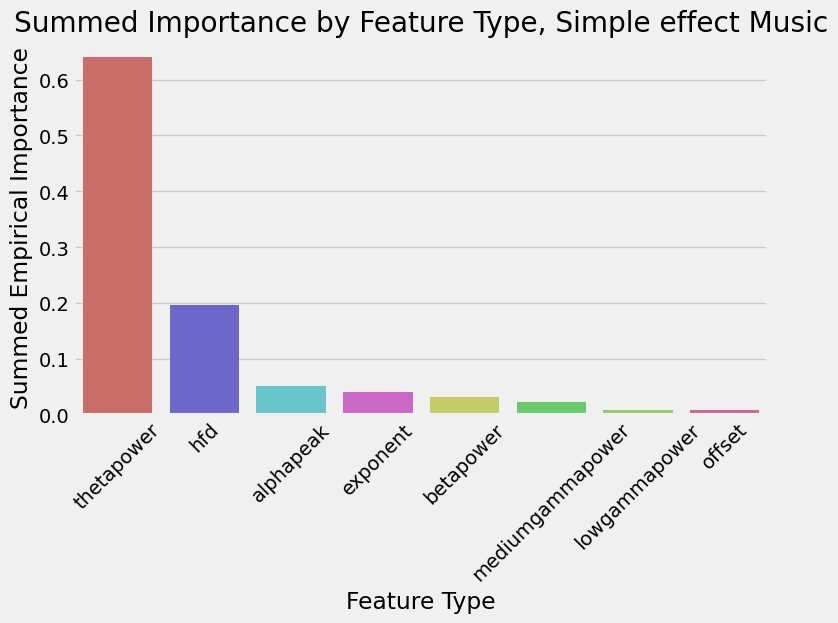

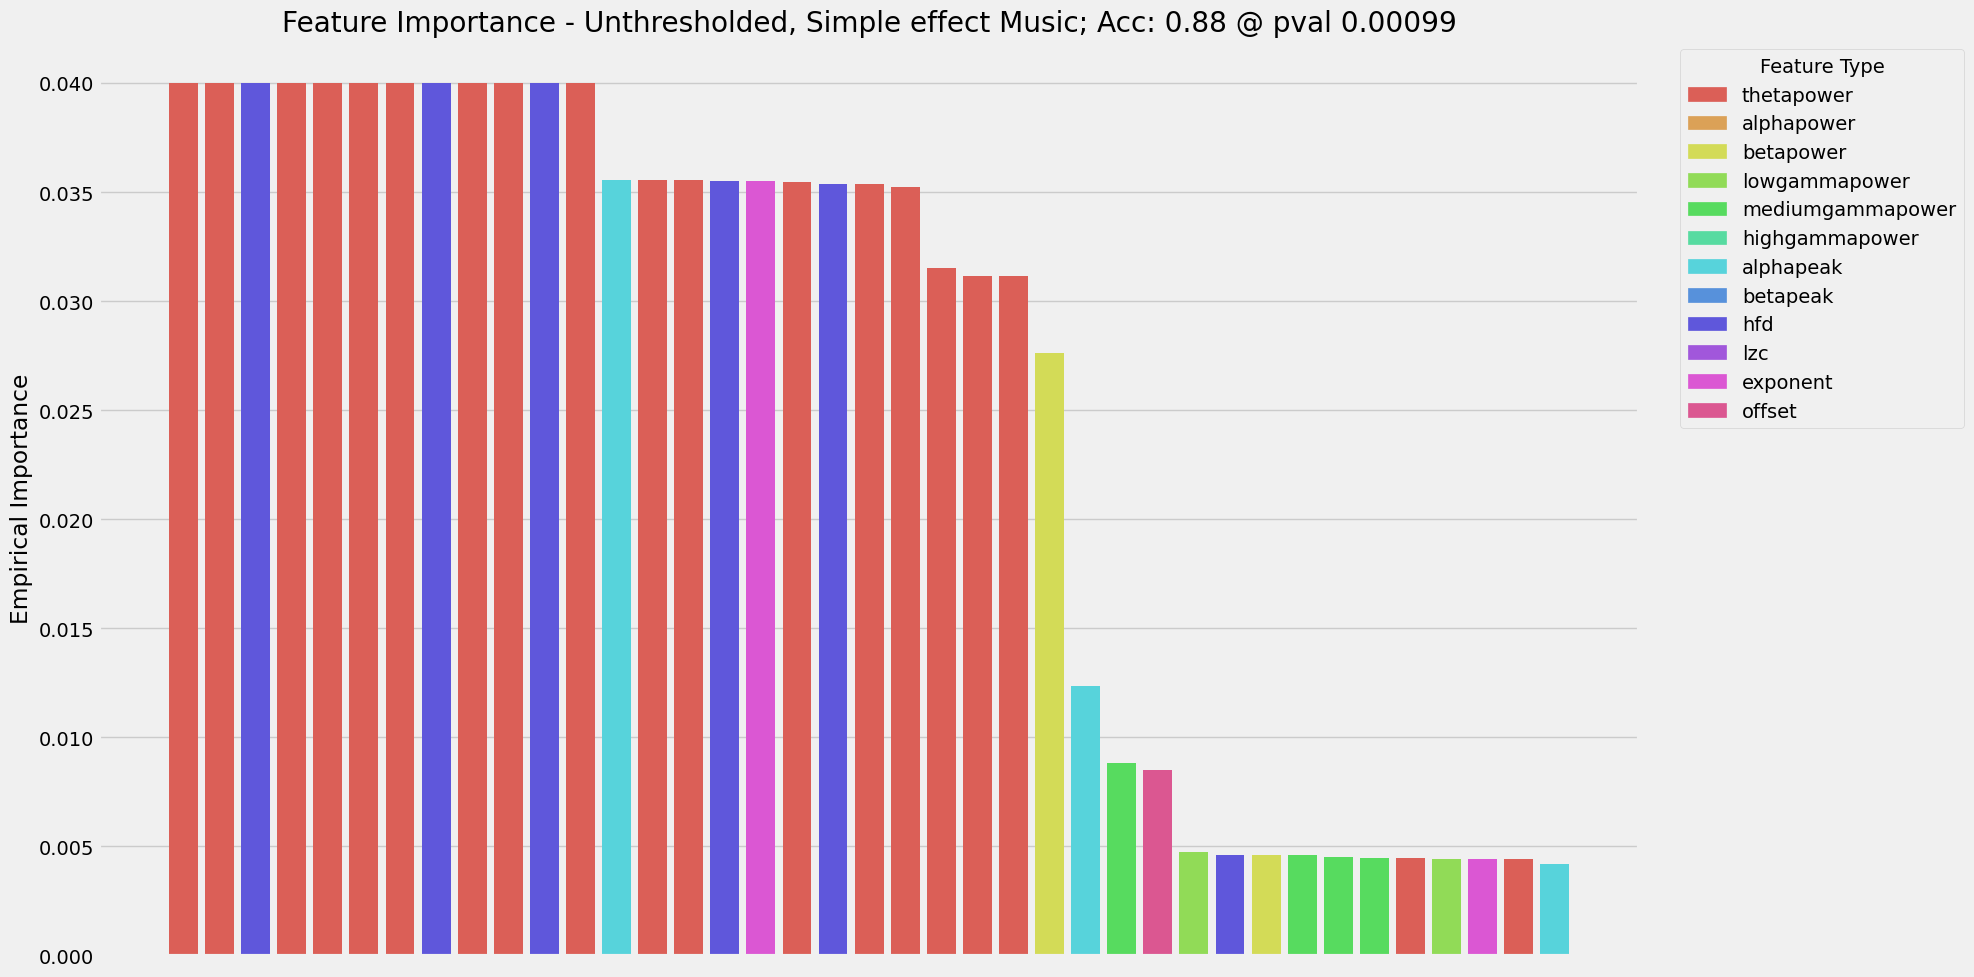

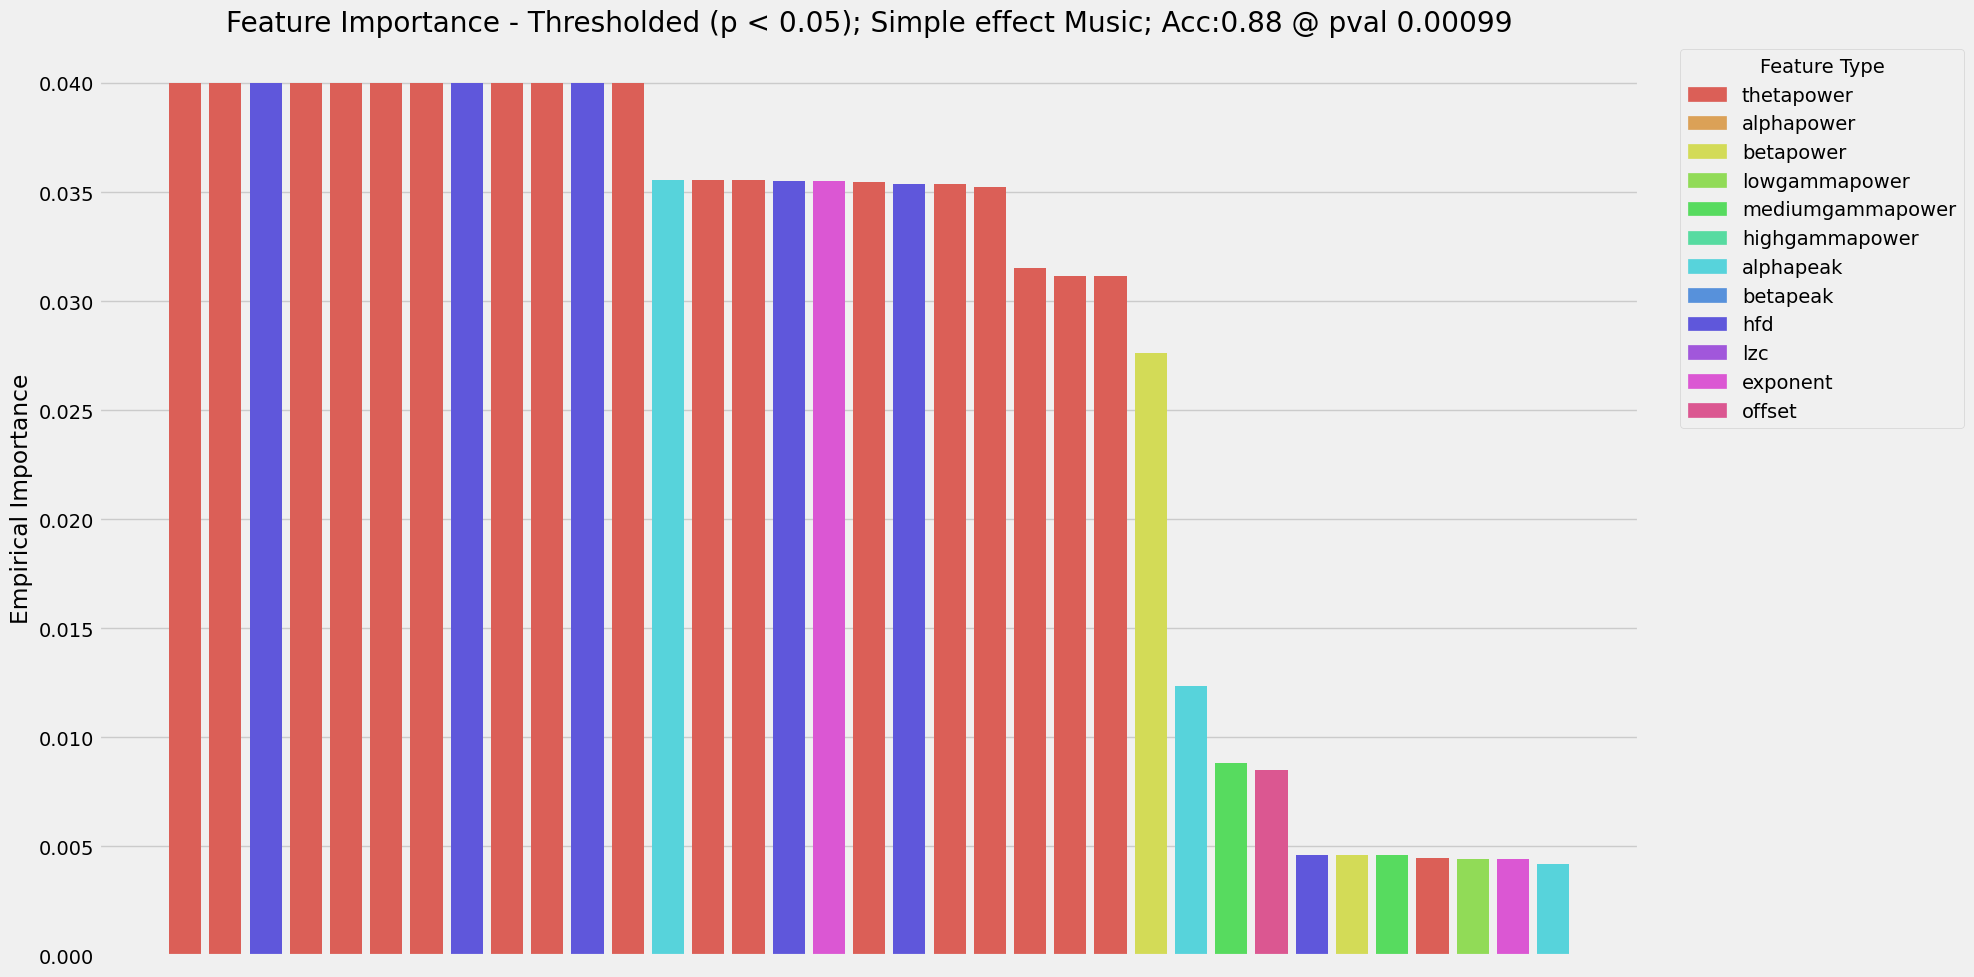

In [20]:
model_type = 'simple_Music'
wheretosave = f"/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/multiFeatureML/results/{model_type}"

df = pd.read_csv(f'/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/data/df_{model_type}.csv')

#remove total power from df
# format is like : totalpower_region1, totalpower_region2, ...
total_power_cols = [col for col in df.columns if col.startswith("totalpower_region")]
if total_power_cols:
    df = df.drop(columns=total_power_cols)

assert 'totalpower_region1' not in df.columns, "Total power columns were not removed properly."
assert len(df.columns)==12*360+2, "Unexpected number of columns after removing total power."

true_best_model, true_accuracy, feature_names, X, y, groups = ml(df=df, is_single_feature=False, whichFeature=None)
feature_importance_df = permtests(true_best_model, true_accuracy, X, y, groups, feature_names)
    
pval_accuracy = np.unique(feature_importance_df['p_value_accuracy'].values)
truncated_pval_accuracy = int(pval_accuracy[0] * 1e5) / 1e5

true_accuracy = np.unique(feature_importance_df['true_accuracy'].values)


plot_feature_importance_group(feature_importance_df, mlmodeltype='Simple effect Music')
feature_importance_plot(feature_importance_df, isThresholded=False, mlmodeltype=f'Simple effect Music; Acc: {true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')
feature_importance_plot(feature_importance_df, isThresholded=True, mlmodeltype=f'Simple effect Music; Acc:{true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')
    
np.savez_compressed(f'{wheretosave}/feature_importance_simple_music.npz', feature_importance_df=feature_importance_df)

# Simple effect NoMusic

Fitting 4 folds for each of 60 candidates, totalling 240 fits


Running permutation test...


100%|██████████| 1000/1000 [11:43<00:00,  1.42it/s]
/tmp/ipykernel_630891/1331509047.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


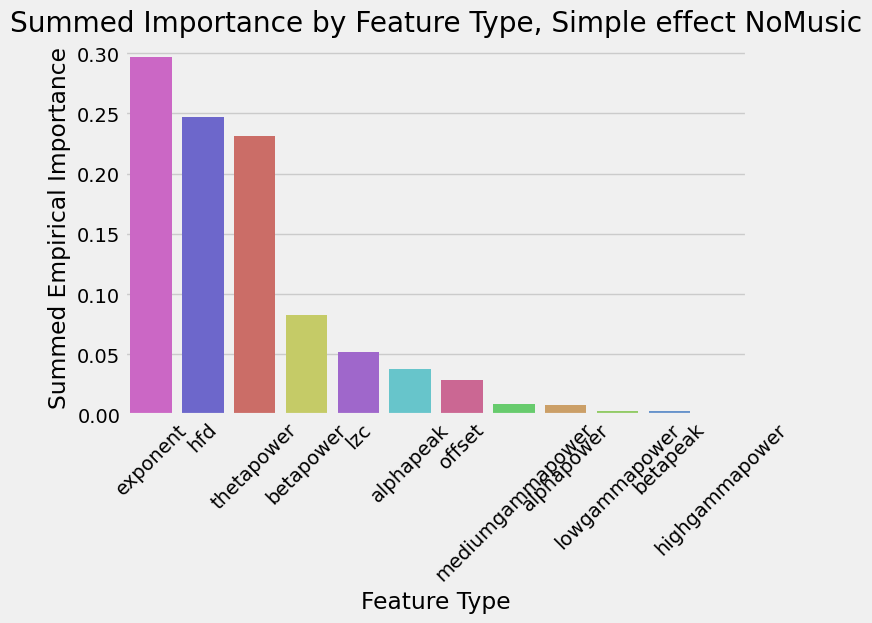

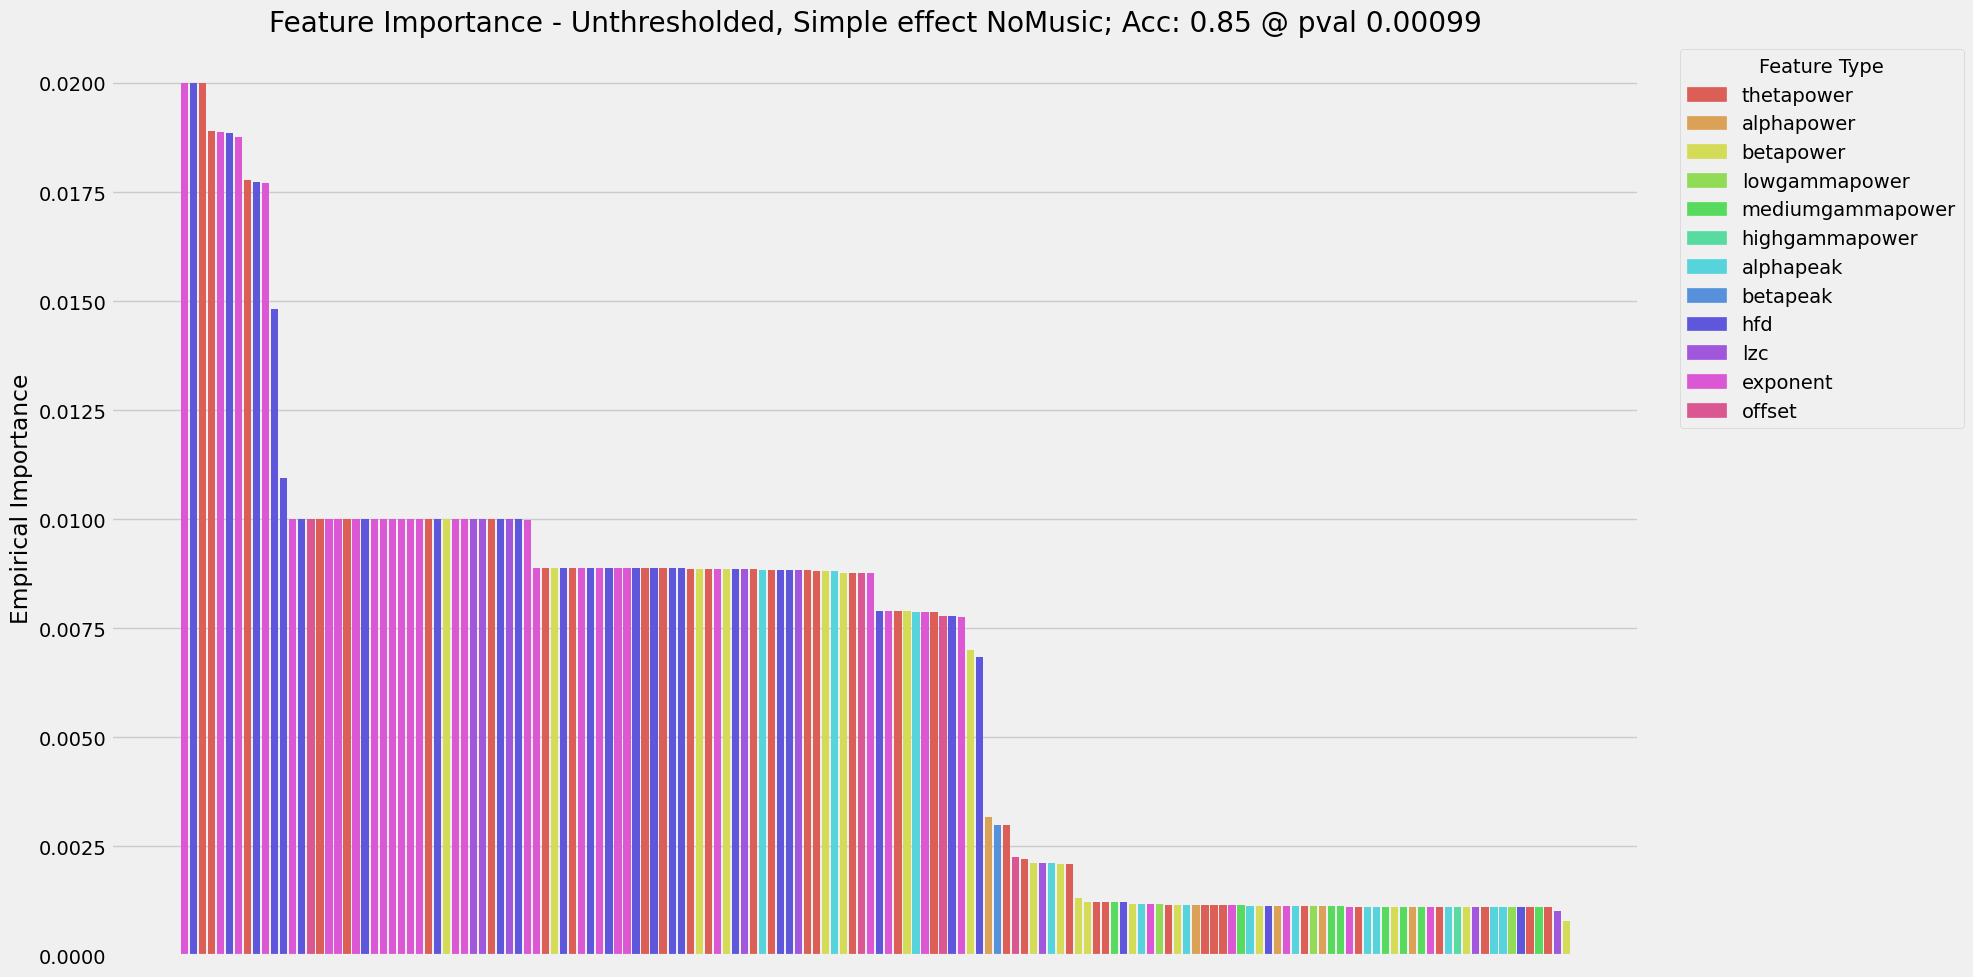

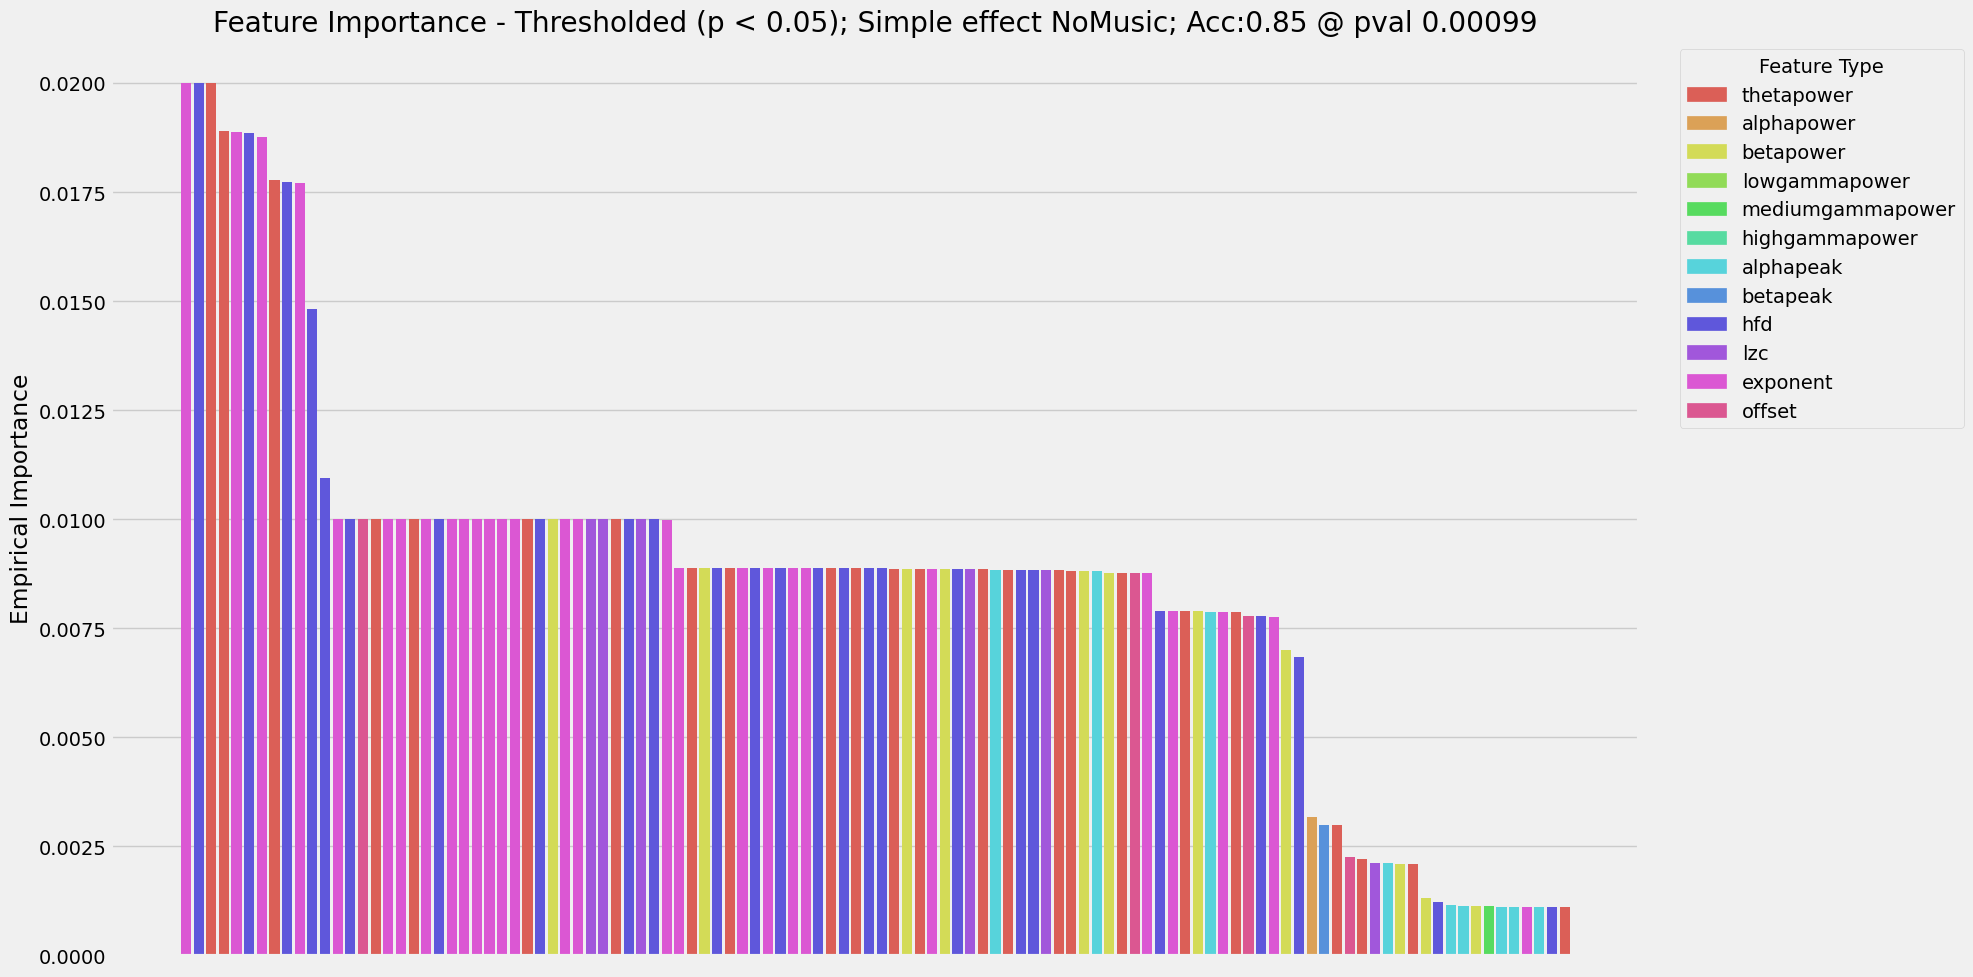

In [21]:
model_type = 'simple_NoMusic'
wheretosave = f"/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/multiFeatureML/results/{model_type}"

df = pd.read_csv(f'/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/data/df_{model_type}.csv')

#remove total power from df
# format is like : totalpower_region1, totalpower_region2, ...
total_power_cols = [col for col in df.columns if col.startswith("totalpower_region")]
if total_power_cols:
    df = df.drop(columns=total_power_cols)

assert 'totalpower_region1' not in df.columns, "Total power columns were not removed properly."
assert len(df.columns)==12*360+2, "Unexpected number of columns after removing total power."

true_best_model, true_accuracy, feature_names, X, y, groups = ml(df=df, is_single_feature=False, whichFeature=None)
feature_importance_df = permtests(true_best_model, true_accuracy, X, y, groups, feature_names)
    
pval_accuracy = np.unique(feature_importance_df['p_value_accuracy'].values)
truncated_pval_accuracy = int(pval_accuracy[0] * 1e5) / 1e5

true_accuracy = np.unique(feature_importance_df['true_accuracy'].values)


plot_feature_importance_group(feature_importance_df, mlmodeltype='Simple effect NoMusic')
feature_importance_plot(feature_importance_df, isThresholded=False, mlmodeltype=f'Simple effect NoMusic; Acc: {true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')
feature_importance_plot(feature_importance_df, isThresholded=True, mlmodeltype=f'Simple effect NoMusic; Acc:{true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')

np.savez_compressed(f'{wheretosave}/feature_importance_simple_nomusic.npz', feature_importance_df=feature_importance_df)

# Main effect Drug

In [ ]:
model_type = 'main_drug'
wheretosave = f"/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/multiFeatureML/results/{model_type}"

df = pd.read_csv(f'/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/data/df_{model_type}.csv')

true_best_model, true_accuracy, feature_names, X, y, groups = ml(df=df, is_single_feature=False, whichFeature=None)
feature_importance_df = permtests(true_best_model, true_accuracy, X, y, groups, feature_names, model_family='multi_feature')
    
pval_accuracy = np.unique(feature_importance_df['p_value_accuracy'].values)
truncated_pval_accuracy = int(pval_accuracy[0] * 1e5) / 1e5

true_accuracy = np.unique(feature_importance_df['true_accuracy'].values)


plot_feature_importance_group(feature_importance_df, mlmodeltype='Main effect Drug')
feature_importance_plot(feature_importance_df, isThresholded=False, mlmodeltype=f'Main effect Drug; Acc: {true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')
feature_importance_plot(feature_importance_df, isThresholded=True, mlmodeltype=f'Main effect Drug; Acc:{true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')

np.savez_compressed(f'{wheretosave}/feature_importance_main_drug.npz', feature_importance_df=feature_importance_df)
    

Fitting 4 folds for each of 60 candidates, totalling 240 fits


Running permutation test...


100%|██████████| 1000/1000 [30:49<00:00,  1.85s/it]


NameError: name 'plot_feature_importance_group' is not defined

/tmp/ipykernel_1122870/4100455957.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


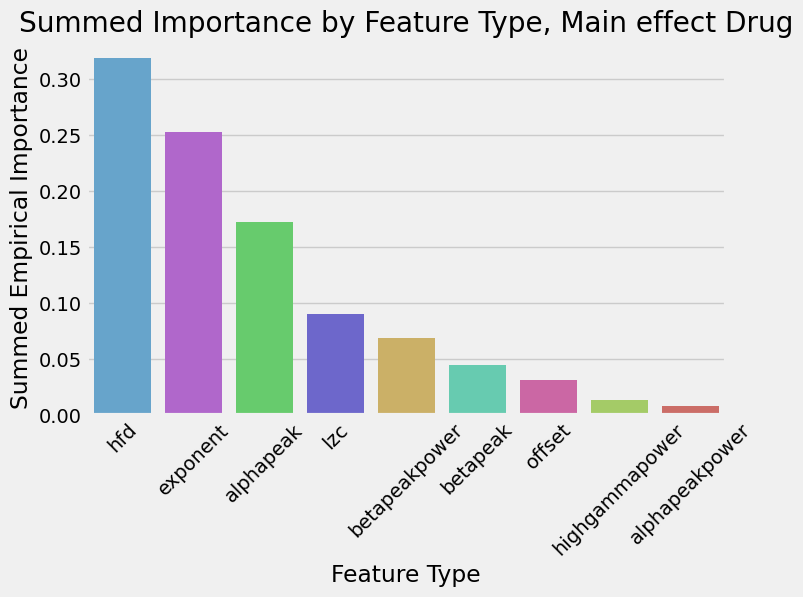

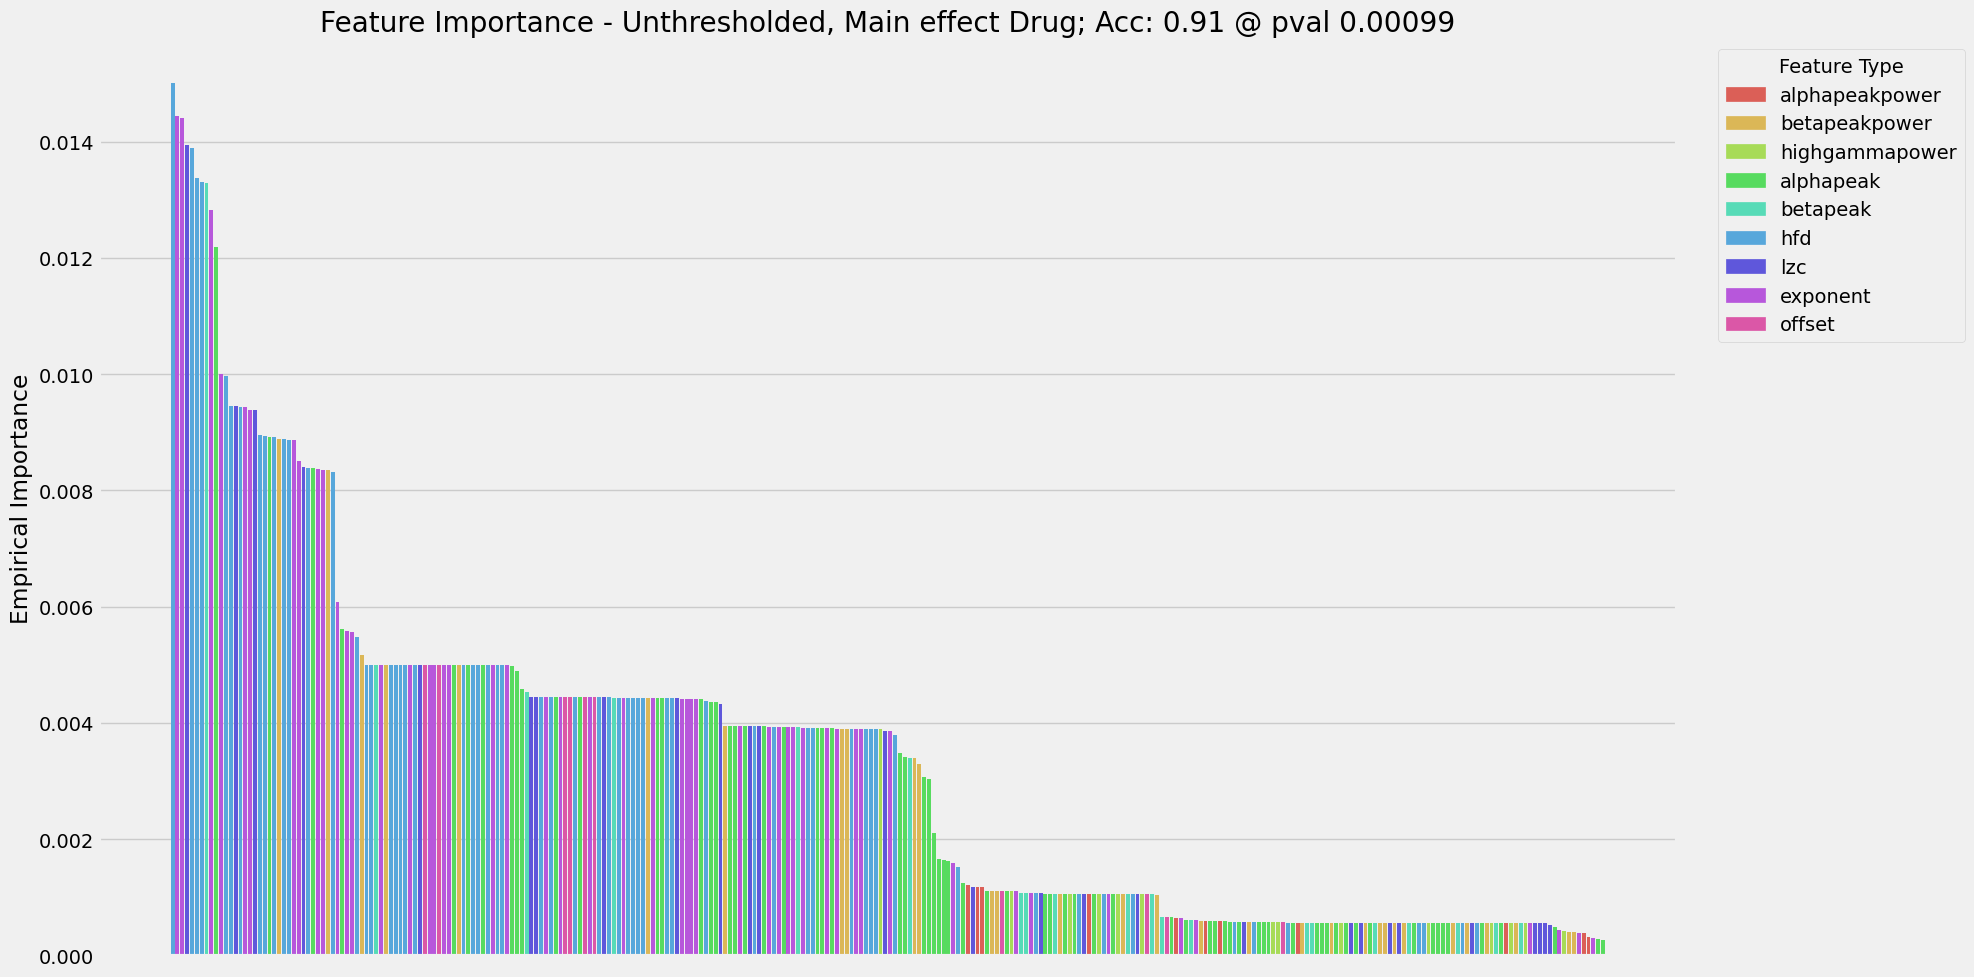

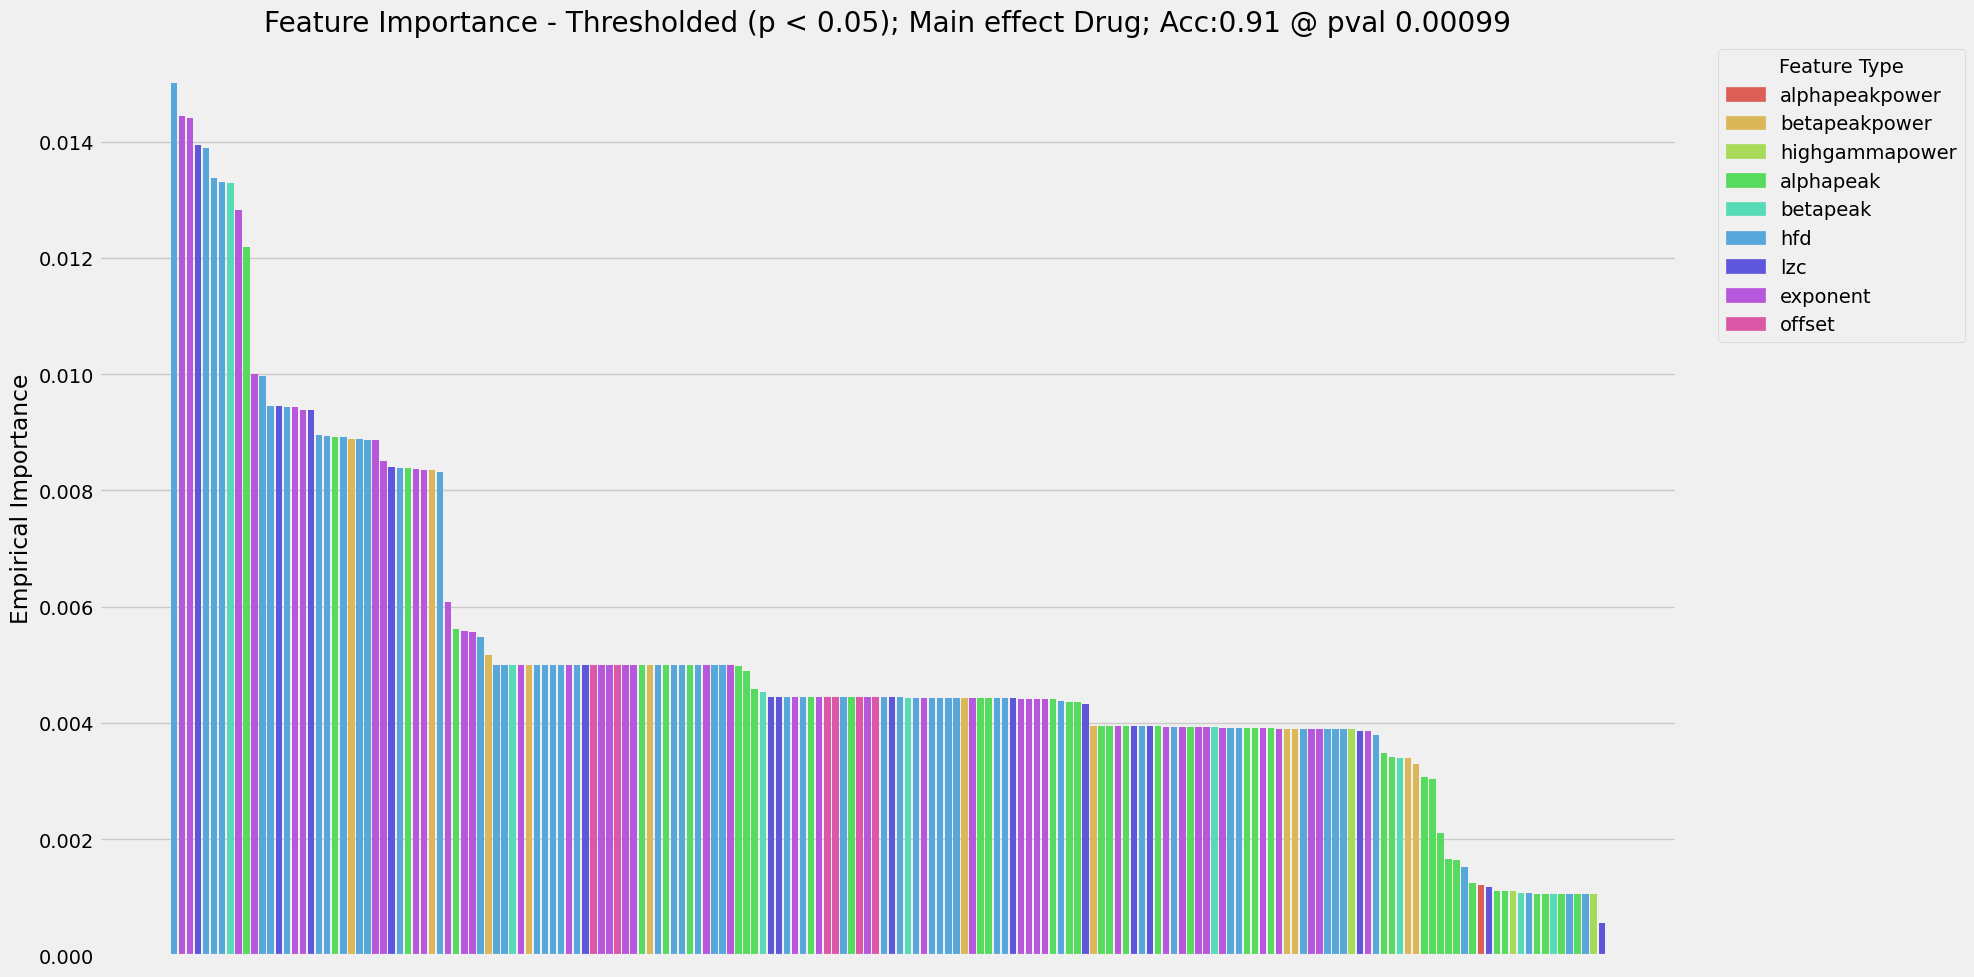

In [26]:

plot_feature_importance_group(feature_importance_df, mlmodeltype='Main effect Drug')
feature_importance_plot(feature_importance_df, isThresholded=False, mlmodeltype=f'Main effect Drug; Acc: {true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')
feature_importance_plot(feature_importance_df, isThresholded=True, mlmodeltype=f'Main effect Drug; Acc:{true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')

np.savez_compressed(f'{wheretosave}/feature_importance_main_drug.npz', feature_importance_df=feature_importance_df)
    

# Interaction effects

Fitting 4 folds for each of 60 candidates, totalling 240 fits


Running permutation test...


100%|██████████| 1000/1000 [11:42<00:00,  1.42it/s]
/tmp/ipykernel_630891/1331509047.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


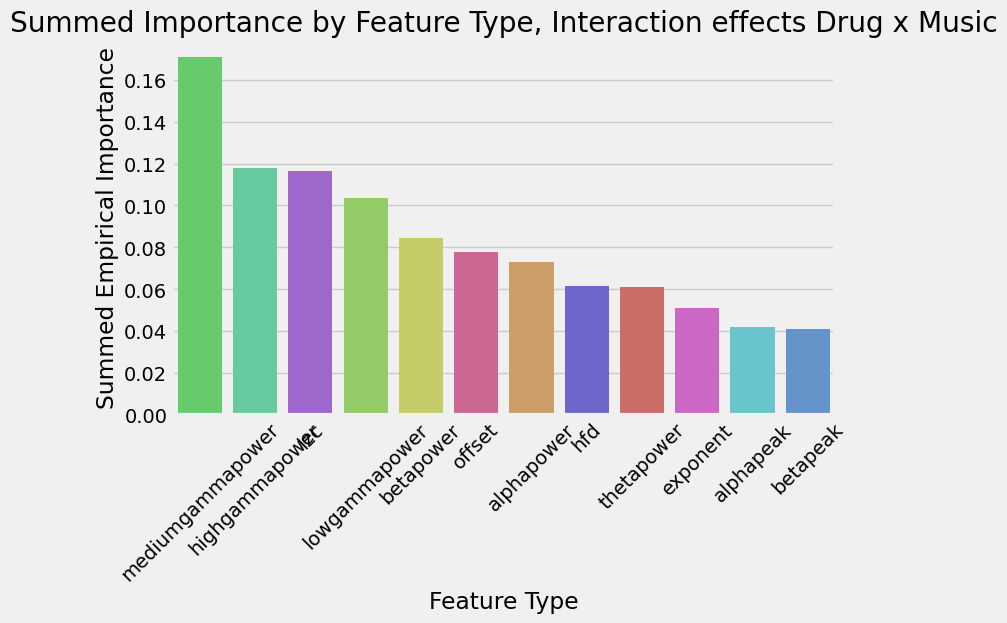

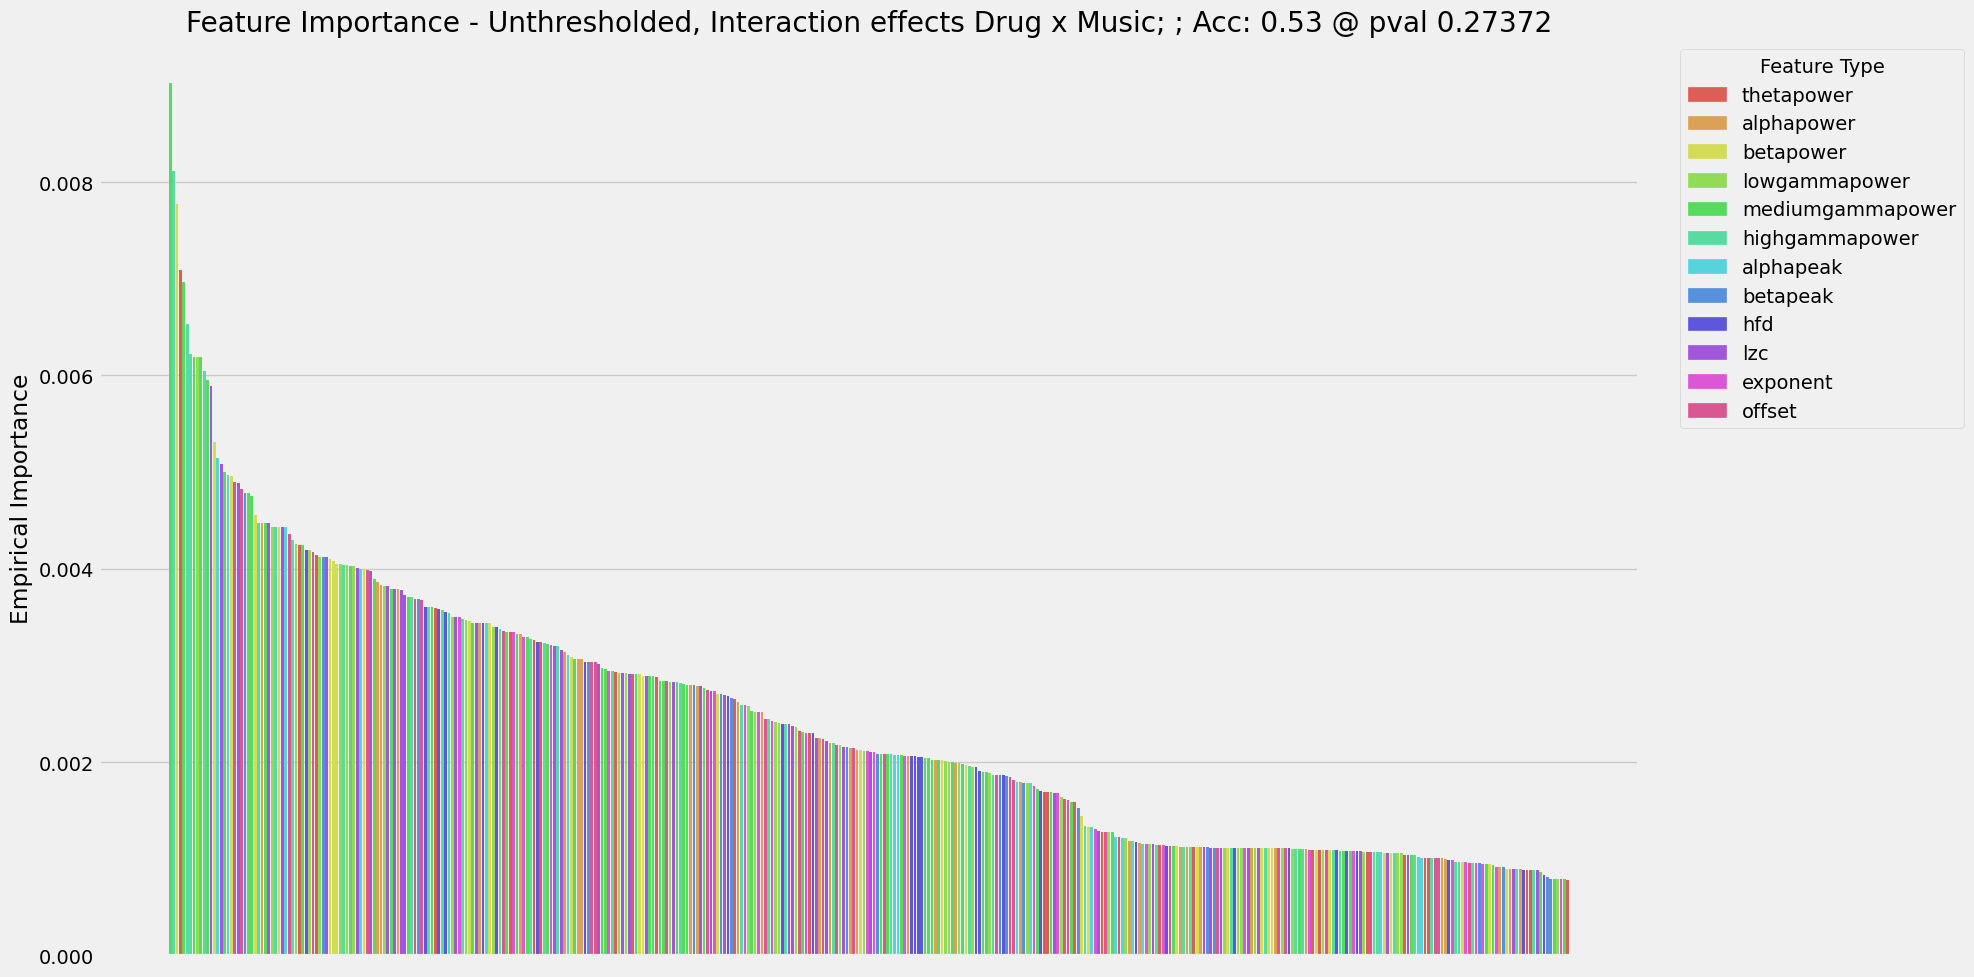

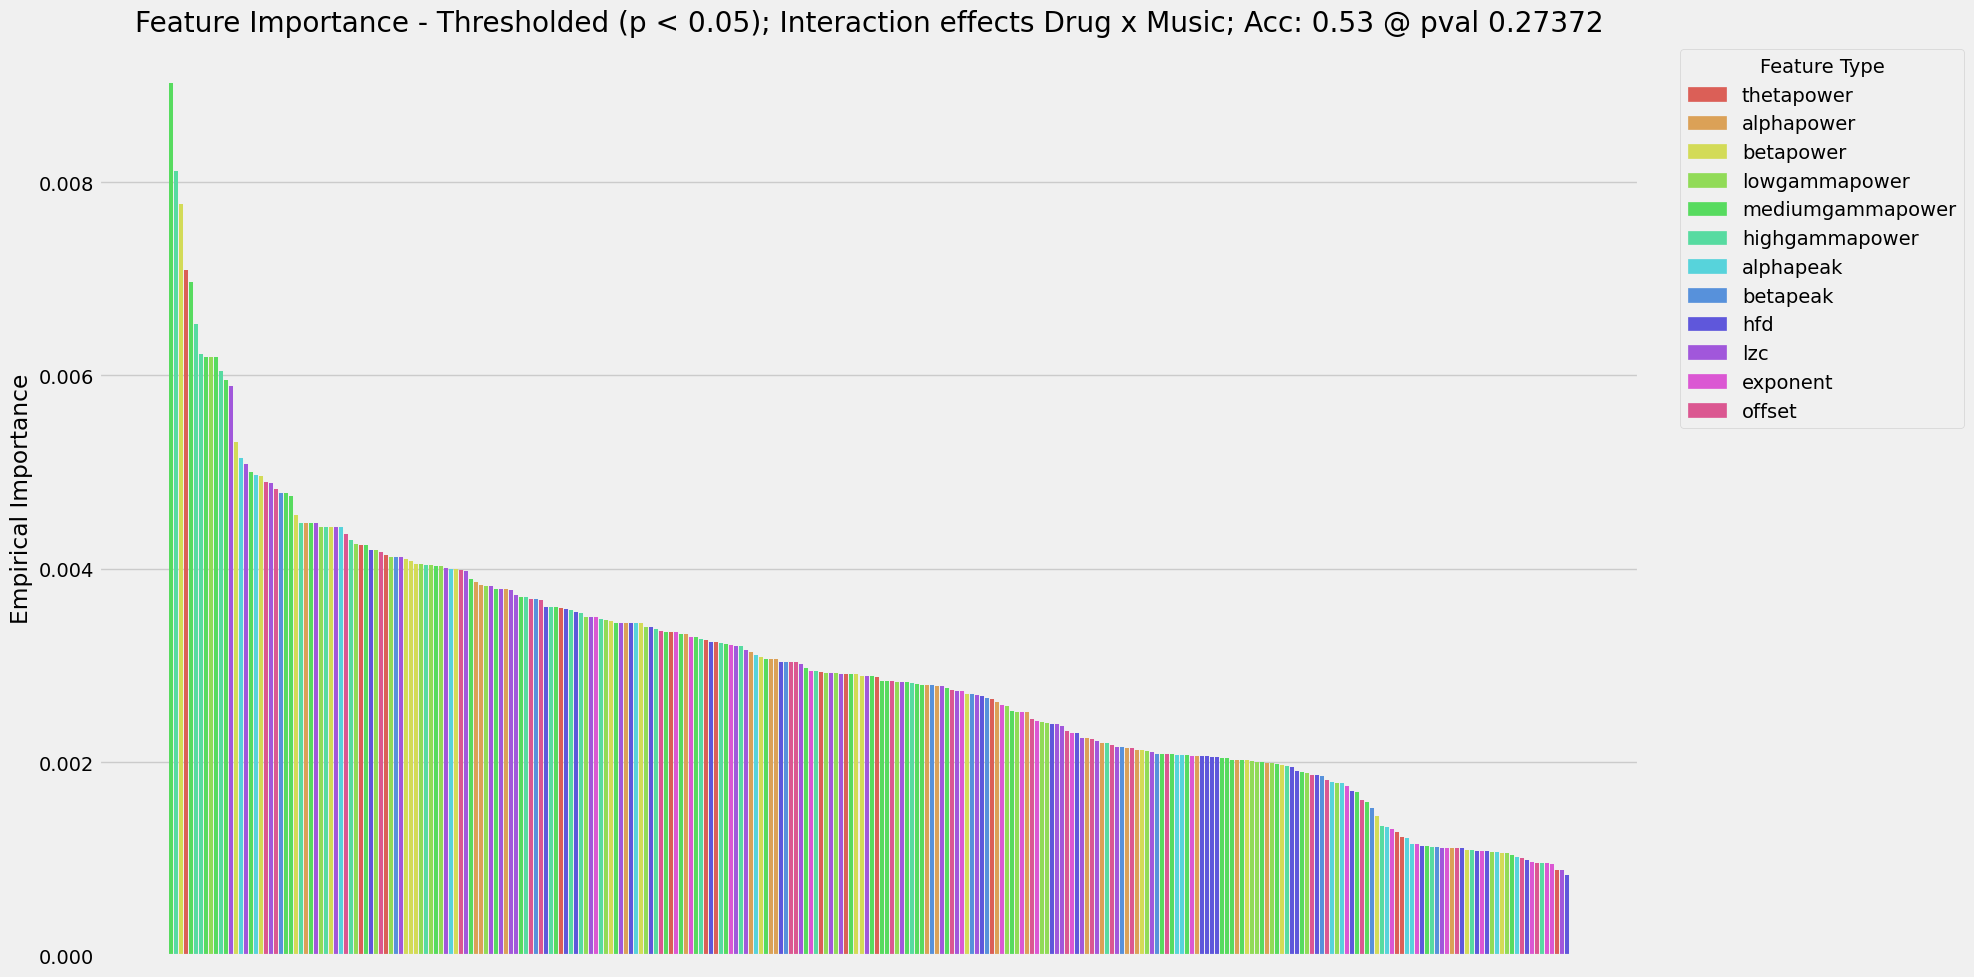

In [ ]:
model_type = 'interaction'
wheretosave = f"/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/multiFeatureML/results/{model_type}"

df = pd.read_csv(f'/Brain/private/v20subra/LSD_project/scripts/Fooof_new/ML/data/df_{model_type}.csv')

#remove total power from df
# format is like : totalpower_region1, totalpower_region2, ...
total_power_cols = [col for col in df.columns if col.startswith("totalpower_region")]
if total_power_cols:
    df = df.drop(columns=total_power_cols)

assert 'totalpower_region1' not in df.columns, "Total power columns were not removed properly."
assert len(df.columns)==12*360+2, "Unexpected number of columns after removing total power."


true_best_model, true_accuracy, feature_names, X, y, groups = ml(df=df, is_single_feature=False, whichFeature=None)
feature_importance_df = permtests(true_best_model, true_accuracy, X, y, groups, feature_names, model_family='multi_feature')
        
pval_accuracy = np.unique(feature_importance_df['p_value_accuracy'].values)
truncated_pval_accuracy = int(pval_accuracy[0] * 1e5) / 1e5

true_accuracy = np.unique(feature_importance_df['true_accuracy'].values)



plot_feature_importance_group(feature_importance_df, mlmodeltype='Interaction effects Drug x Music')
feature_importance_plot(feature_importance_df, isThresholded=False, mlmodeltype=f'Interaction effects Drug x Music; ; Acc: {true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')
feature_importance_plot(feature_importance_df, isThresholded=True, mlmodeltype=f'Interaction effects Drug x Music; Acc: {true_accuracy[0]:.2f} @ pval {truncated_pval_accuracy}')

np.savez_compressed(f'{wheretosave}/feature_importance_interaction_effect.npz', feature_importance_df=feature_importance_df)